STUDENT PLACEMENT DATASET
   CGPA  AptitudeScore  TechnicalScore  CommunicationScore Internship Branch  \
0   6.2             45              40                  50         No    CSE   
1   6.5             50              45                  52         No    ECE   
2   6.8             52              48                  55         No    CSE   
3   7.0             55              52                  58        Yes     IT   
4   7.2             58              55                  60         No    ECE   

  PlacementStatus  
0      Not Placed  
1      Not Placed  
2      Not Placed  
3          Placed  
4      Not Placed  

Dataset Shape:
(30, 7)

FEATURE TYPES
Numerical Features:
['CGPA', 'AptitudeScore', 'TechnicalScore', 'CommunicationScore']

Categorical Features:
['Internship', 'Branch']

TRAIN / VALIDATION DATA
Training samples: 24
Validation samples: 6


RANDOM FOREST
Train Accuracy: 1.0
Validation Accuracy: 1.0
OOB Accuracy: 0.9166666666666666
OOB Error: 0.08333333333333337

Classi

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


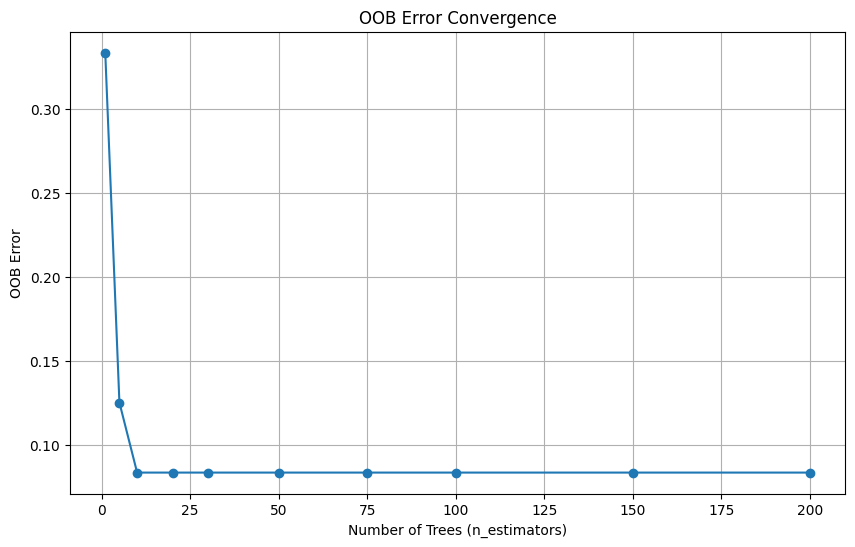

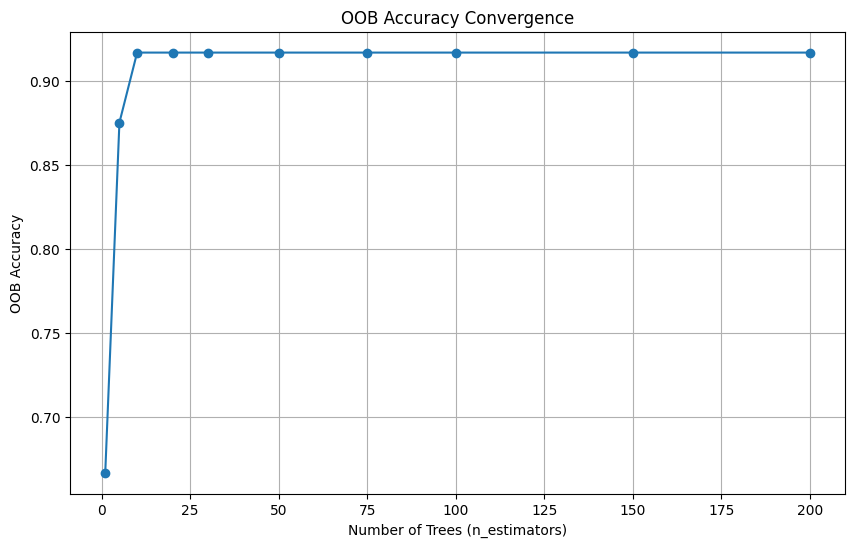



max_features COMPARISON
max_features  Validation Accuracy  OOB Accuracy  OOB Error
        sqrt                  1.0      0.916667   0.083333
        log2                  1.0      0.916667   0.083333
        None                  1.0      0.958333   0.041667


MANUAL BOOTSTRAP BAGGING
Number of bootstrap trees: 50
Validation Accuracy: 1.0


PERMUTATION FEATURE IMPORTANCE
                Feature  Importance
     cat__Internship_No         0.1
    cat__Internship_Yes         0.1
              num__CGPA         0.0
    num__TechnicalScore         0.0
     num__AptitudeScore         0.0
num__CommunicationScore         0.0
        cat__Branch_CSE         0.0
        cat__Branch_ECE         0.0
         cat__Branch_IT         0.0


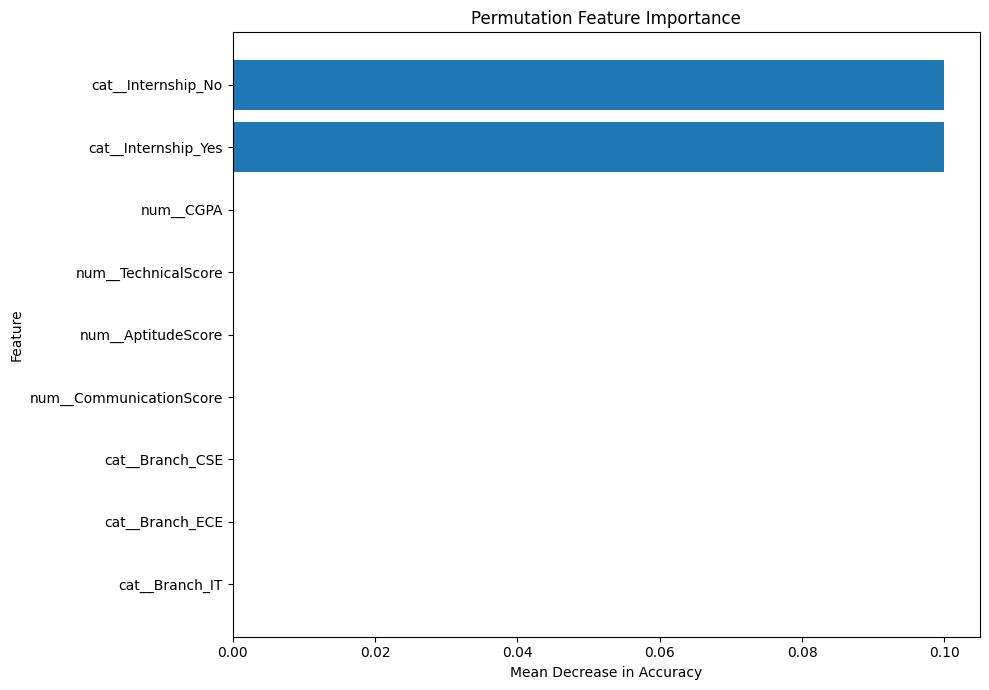

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


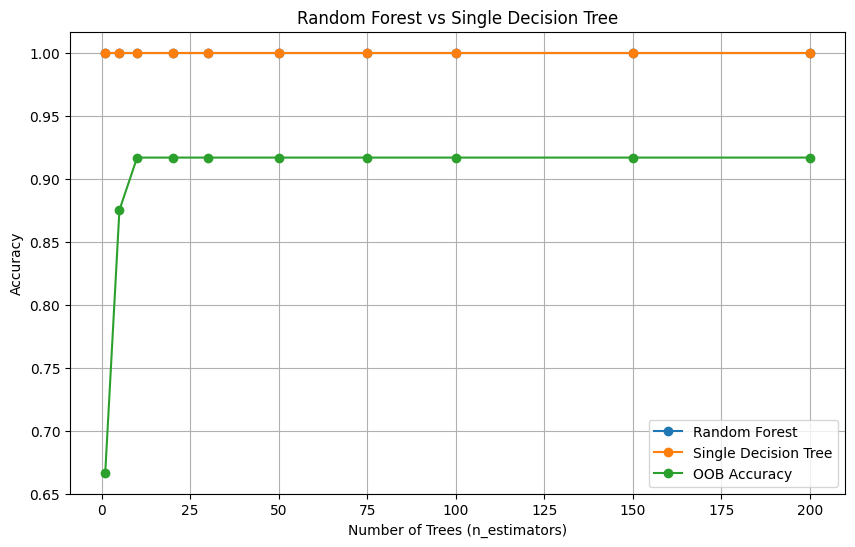



RANDOM FOREST VS SINGLE DECISION TREE
 n_estimators  RF_val_acc  DT_val_acc  OOB_acc
            1         1.0         1.0 0.666667
            5         1.0         1.0 0.875000
           10         1.0         1.0 0.916667
           20         1.0         1.0 0.916667
           30         1.0         1.0 0.916667
           50         1.0         1.0 0.916667
           75         1.0         1.0 0.916667
          100         1.0         1.0 0.916667
          150         1.0         1.0 0.916667
          200         1.0         1.0 0.916667


SESSION 7 ANALYSIS

RANDOM FOREST:
- Random Forest is an ensemble of Decision Trees.
- Multiple trees are trained using bootstrap samples.
- Their predictions are combined to make the final prediction.

BAGGING:
- Bagging means Bootstrap Aggregating.
- Multiple bootstrap samples are created from the training data.
- A model is trained on each sample.
- Predictions are combined using majority voting.

OOB EVALUATION:
- OOB means Out-Of-Ba

In [1]:
# ================================================================
# MACHINE LEARNING PRACTICAL - SESSION 7
# ================================================================
# TOPIC:
# Random Forest, Bagging and Out-of-Bag Evaluation
#
# Includes:
# 1. Random Forest Classification
# 2. OOB Accuracy / OOB Error
# 3. OOB Error Convergence
# 4. max_features Comparison
# 5. Manual Bootstrap Bagging
# 6. Permutation Feature Importance
# 7. Random Forest vs Single Decision Tree
# 8. rf_vs_single_tree() Function
# 9. Different n_estimators
# 10. Three-line comparison plot
# ================================================================


# ----------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ----------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    classification_report
)


# =================================================================
# 2. CREATE STUDENT PLACEMENT DATASET
# =================================================================
# No external dataset is required.
# The complete dataset is created directly inside Colab.
#
# Features:
# CGPA
# AptitudeScore
# TechnicalScore
# CommunicationScore
# Internship
# Branch
#
# Target:
# PlacementStatus
# =================================================================


data = {

    'CGPA': [
        6.2, 6.5, 6.8, 7.0, 7.2,
        7.4, 7.6, 7.8, 8.0, 8.2,
        8.4, 8.6, 8.8, 9.0, 9.2,
        9.4, 6.1, 6.7, 7.1, 7.5,
        7.9, 8.3, 8.7, 9.1, 6.4,
        6.9, 7.3, 7.7, 8.1, 8.5
    ],

    'AptitudeScore': [
        45, 50, 52, 55, 58,
        60, 62, 65, 68, 70,
        72, 75, 78, 80, 85,
        88, 42, 48, 56, 61,
        67, 73, 77, 83, 46,
        54, 59, 64, 71, 76
    ],

    'TechnicalScore': [
        40, 45, 48, 52, 55,
        58, 60, 64, 67, 70,
        72, 76, 79, 82, 86,
        90, 38, 44, 50, 57,
        63, 69, 75, 84, 43,
        49, 55, 62, 68, 74
    ],

    'CommunicationScore': [
        50, 52, 55, 58, 60,
        62, 65, 67, 70, 72,
        74, 76, 79, 82, 85,
        88, 48, 54, 57, 61,
        64, 68, 73, 80, 51,
        56, 59, 63, 69, 75
    ],

    'Internship': [
        'No', 'No', 'No', 'Yes', 'No',
        'Yes', 'Yes', 'No', 'Yes', 'Yes',
        'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
        'Yes', 'No', 'No', 'No', 'Yes',
        'Yes', 'Yes', 'Yes', 'Yes', 'No',
        'No', 'Yes', 'Yes', 'Yes', 'Yes'
    ],

    'Branch': [
        'CSE', 'ECE', 'CSE', 'IT', 'ECE',
        'CSE', 'IT', 'CSE', 'ECE', 'CSE',
        'IT', 'CSE', 'ECE', 'CSE', 'IT',
        'CSE', 'ECE', 'CSE', 'IT', 'ECE',
        'CSE', 'IT', 'CSE', 'ECE', 'IT',
        'CSE', 'ECE', 'IT', 'CSE', 'CSE'
    ],

    'PlacementStatus': [
        'Not Placed', 'Not Placed', 'Not Placed',
        'Placed', 'Not Placed', 'Placed',
        'Placed', 'Not Placed', 'Placed',
        'Placed', 'Placed', 'Placed', 'Placed',
        'Placed', 'Placed', 'Placed',
        'Not Placed', 'Not Placed', 'Not Placed',
        'Placed', 'Placed', 'Placed', 'Placed',
        'Placed', 'Not Placed', 'Not Placed',
        'Placed', 'Placed', 'Placed', 'Placed'
    ]
}


# Convert dictionary into DataFrame

df = pd.DataFrame(data)


print("=" * 70)
print("STUDENT PLACEMENT DATASET")
print("=" * 70)

print(df.head())

print("\nDataset Shape:")
print(df.shape)


# =================================================================
# 3. SEPARATE FEATURES AND TARGET
# =================================================================

X = df.drop(
    columns=['PlacementStatus']
)

y = df['PlacementStatus']


# =================================================================
# 4. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# =================================================================

numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=['object']
).columns.tolist()


print("\n" + "=" * 70)
print("FEATURE TYPES")
print("=" * 70)

print("Numerical Features:")
print(numerical_cols)

print("\nCategorical Features:")
print(categorical_cols)


# =================================================================
# 5. ONE-HOT ENCODING
# =================================================================
# Random Forest does not need feature scaling.
#
# However, categorical variables such as:
# CSE / ECE / IT
#
# must be converted into numerical form.
#
# Therefore, we use One-Hot Encoding.
# =================================================================


preprocessor = ColumnTransformer(

    transformers=[

        (
            'num',
            'passthrough',
            numerical_cols
        ),

        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_cols
        )
    ]
)


# =================================================================
# 6. TRAIN / VALIDATION SPLIT
# =================================================================


X_train, X_val, y_train, y_val = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)


print("\n" + "=" * 70)
print("TRAIN / VALIDATION DATA")
print("=" * 70)

print("Training samples:",
      len(X_train))

print("Validation samples:",
      len(X_val))


# =================================================================
# 7. RANDOM FOREST MODEL
# =================================================================
#
# Random Forest is an ensemble learning method.
#
# It creates many Decision Trees and combines their predictions.
#
# n_estimators:
# Number of trees in the forest.
#
# max_features:
# Number of features considered when splitting each node.
#
# oob_score=True:
# Enables Out-of-Bag evaluation.
# =================================================================


rf_model = Pipeline([

    (
        'preprocessor',
        preprocessor
    ),

    (
        'classifier',
        RandomForestClassifier(
            n_estimators=100,
            max_features='sqrt',
            bootstrap=True,
            oob_score=True,
            random_state=42
        )
    )
])


# Train Random Forest

rf_model.fit(
    X_train,
    y_train
)


# Predictions

rf_train_pred = rf_model.predict(
    X_train
)

rf_val_pred = rf_model.predict(
    X_val
)


# Accuracy

rf_train_acc = accuracy_score(
    y_train,
    rf_train_pred
)

rf_val_acc = accuracy_score(
    y_val,
    rf_val_pred
)


# OOB accuracy

rf_oob_acc = (
    rf_model
    .named_steps['classifier']
    .oob_score_
)


print("\n")
print("=" * 70)
print("RANDOM FOREST")
print("=" * 70)

print("Train Accuracy:",
      rf_train_acc)

print("Validation Accuracy:",
      rf_val_acc)

print("OOB Accuracy:",
      rf_oob_acc)

print("OOB Error:",
      1 - rf_oob_acc)


# =================================================================
# 8. CLASSIFICATION REPORT
# =================================================================


print("\nClassification Report:")

print(
    classification_report(
        y_val,
        rf_val_pred
    )
)


# =================================================================
# 9. OOB ERROR CONVERGENCE
# =================================================================
#
# We increase the number of trees.
#
# As more trees are added, the OOB accuracy generally becomes
# more stable.
#
# OOB Error = 1 - OOB Accuracy
# =================================================================


n_estimators_values = [
    1,
    5,
    10,
    20,
    30,
    50,
    75,
    100,
    150,
    200
]


oob_accuracy_values = []

oob_error_values = []


for n in n_estimators_values:

    # Random Forest

    model = Pipeline([

        (
            'preprocessor',
            preprocessor
        ),

        (
            'classifier',
            RandomForestClassifier(

                n_estimators=n,

                max_features='sqrt',

                bootstrap=True,

                oob_score=True,

                random_state=42
            )
        )
    ])


    # Train

    model.fit(
        X_train,
        y_train
    )


    # Get OOB accuracy

    oob_acc = (
        model
        .named_steps['classifier']
        .oob_score_
    )


    oob_accuracy_values.append(
        oob_acc
    )


    oob_error_values.append(
        1 - oob_acc
    )


# =================================================================
# 10. OOB ERROR CONVERGENCE GRAPH
# =================================================================


plt.figure(
    figsize=(10, 6)
)


plt.plot(

    n_estimators_values,

    oob_error_values,

    marker='o'
)


plt.xlabel(
    'Number of Trees (n_estimators)'
)


plt.ylabel(
    'OOB Error'
)


plt.title(
    'OOB Error Convergence'
)


plt.grid(True)


plt.show()


# =================================================================
# 11. OOB ACCURACY CONVERGENCE GRAPH
# =================================================================


plt.figure(
    figsize=(10, 6)
)


plt.plot(

    n_estimators_values,

    oob_accuracy_values,

    marker='o'
)


plt.xlabel(
    'Number of Trees (n_estimators)'
)


plt.ylabel(
    'OOB Accuracy'
)


plt.title(
    'OOB Accuracy Convergence'
)


plt.grid(True)


plt.show()


# =================================================================
# 12. max_features COMPARISON
# =================================================================
#
# max_features controls how many features are considered
# when searching for the best split.
#
# Common choices:
#
# sqrt
# log2
# None
# =================================================================


max_features_values = [
    'sqrt',
    'log2',
    None
]


max_features_results = []


for mf in max_features_values:

    model = Pipeline([

        (
            'preprocessor',
            preprocessor
        ),

        (
            'classifier',
            RandomForestClassifier(

                n_estimators=100,

                max_features=mf,

                bootstrap=True,

                oob_score=True,

                random_state=42
            )
        )
    ])


    model.fit(
        X_train,
        y_train
    )


    val_prediction = model.predict(
        X_val
    )


    validation_accuracy = accuracy_score(
        y_val,
        val_prediction
    )


    oob_accuracy = (
        model
        .named_steps['classifier']
        .oob_score_
    )


    max_features_results.append({

        'max_features':
        str(mf),

        'Validation Accuracy':
        validation_accuracy,

        'OOB Accuracy':
        oob_accuracy,

        'OOB Error':
        1 - oob_accuracy
    })


max_features_df = pd.DataFrame(
    max_features_results
)


print("\n")
print("=" * 70)
print("max_features COMPARISON")
print("=" * 70)

print(
    max_features_df.to_string(
        index=False
    )
)


# =================================================================
# 13. MANUAL BOOTSTRAP BAGGING
# =================================================================
#
# Bagging means:
#
# 1. Create multiple bootstrap samples.
# 2. Train a Decision Tree on each sample.
# 3. Combine their predictions.
#
# A bootstrap sample is created by sampling training rows
# WITH replacement.
# =================================================================


# Convert preprocessed training data to numerical matrix

X_train_transformed = (
    preprocessor.fit_transform(
        X_train
    )
)

X_val_transformed = (
    preprocessor.transform(
        X_val
    )
)


# Convert sparse matrix if necessary

if hasattr(
    X_train_transformed,
    "toarray"
):

    X_train_transformed = (
        X_train_transformed.toarray()
    )

    X_val_transformed = (
        X_val_transformed.toarray()
    )


# Convert target to numeric labels

y_train_array = np.array(
    y_train
)

y_val_array = np.array(
    y_val
)


# Number of bootstrap trees

n_bootstrap_trees = 50


bootstrap_predictions = []


rng = np.random.RandomState(
    42
)


for i in range(
    n_bootstrap_trees
):

    # Randomly select training indices
    # WITH replacement

    sample_indices = rng.choice(

        len(X_train_transformed),

        size=len(X_train_transformed),

        replace=True
    )


    # Bootstrap sample

    X_bootstrap = (
        X_train_transformed[
            sample_indices
        ]
    )

    y_bootstrap = (
        y_train_array[
            sample_indices
        ]
    )


    # Train Decision Tree

    tree = DecisionTreeClassifier(
        random_state=i,
        max_depth=5
    )


    tree.fit(
        X_bootstrap,
        y_bootstrap
    )


    # Predict validation data

    prediction = tree.predict(
        X_val_transformed
    )


    bootstrap_predictions.append(
        prediction
    )


# Convert predictions to array

bootstrap_predictions = np.array(
    bootstrap_predictions
)


# =================================================================
# 14. MAJORITY VOTE
# =================================================================
#
# Each tree gives one prediction.
#
# The final class is the class receiving the most votes.
# =================================================================


manual_bagging_prediction = []


for column in bootstrap_predictions.T:

    values, counts = np.unique(
        column,
        return_counts=True
    )


    majority_class = values[
        np.argmax(counts)
    ]


    manual_bagging_prediction.append(
        majority_class
    )


manual_bagging_prediction = np.array(
    manual_bagging_prediction
)


manual_bagging_accuracy = accuracy_score(

    y_val_array,

    manual_bagging_prediction
)


print("\n")
print("=" * 70)
print("MANUAL BOOTSTRAP BAGGING")
print("=" * 70)

print(
    "Number of bootstrap trees:",
    n_bootstrap_trees
)

print(
    "Validation Accuracy:",
    manual_bagging_accuracy
)


# =================================================================
# 15. PERMUTATION FEATURE IMPORTANCE
# =================================================================
#
# Permutation importance measures how much model performance
# decreases when a feature is randomly shuffled.
#
# If shuffling a feature reduces performance significantly,
# that feature is important to the model.
# =================================================================


# Train final Random Forest on transformed data

rf_transformed = RandomForestClassifier(

    n_estimators=100,

    max_features='sqrt',

    random_state=42
)


rf_transformed.fit(

    X_train_transformed,

    y_train
)


# Calculate permutation importance

perm = permutation_importance(

    rf_transformed,

    X_val_transformed,

    y_val,

    n_repeats=10,

    random_state=42
)


# Get feature names

feature_names = (
    preprocessor
    .get_feature_names_out()
)


# Create DataFrame

importance_df = pd.DataFrame({

    'Feature':
    feature_names,

    'Importance':
    perm.importances_mean
})


# Sort by importance

importance_df = (
    importance_df
    .sort_values(
        by='Importance',
        ascending=False
    )
)


print("\n")
print("=" * 70)
print("PERMUTATION FEATURE IMPORTANCE")
print("=" * 70)

print(
    importance_df.to_string(
        index=False
    )
)


# =================================================================
# 16. PLOT PERMUTATION IMPORTANCE
# =================================================================


plt.figure(
    figsize=(10, 7)
)


plt.barh(

    importance_df['Feature'],

    importance_df['Importance']
)


plt.xlabel(
    'Mean Decrease in Accuracy'
)


plt.ylabel(
    'Feature'
)


plt.title(
    'Permutation Feature Importance'
)


plt.gca().invert_yaxis()


plt.tight_layout()


plt.show()


# =================================================================
# 17. rf_vs_single_tree() FUNCTION
# =================================================================
#
# This function compares:
#
# Random Forest
# VS
# Single Decision Tree
#
# for different values of n_estimators.
#
# Required output:
#
# n_estimators
# RF_val_acc
# DT_val_acc
# OOB_acc
# =================================================================


def rf_vs_single_tree(

    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators_list

):


    results = []


    for n in n_estimators_list:


        # --------------------------------------------------------
        # RANDOM FOREST
        # --------------------------------------------------------

        rf = Pipeline([

            (
                'preprocessor',
                preprocessor
            ),

            (
                'classifier',
                RandomForestClassifier(

                    n_estimators=n,

                    max_features='sqrt',

                    bootstrap=True,

                    oob_score=True,

                    random_state=42
                )
            )
        ])


        # Train Random Forest

        rf.fit(
            X_train,
            y_train
        )


        # RF validation prediction

        rf_prediction = rf.predict(
            X_val
        )


        # RF validation accuracy

        rf_accuracy = accuracy_score(

            y_val,

            rf_prediction
        )


        # OOB accuracy

        oob_accuracy = (
            rf
            .named_steps['classifier']
            .oob_score_
        )


        # --------------------------------------------------------
        # SINGLE DECISION TREE
        # --------------------------------------------------------
        #
        # The number of trees does not affect a single tree.
        # We still calculate its accuracy for comparison.
        # --------------------------------------------------------


        dt = Pipeline([

            (
                'preprocessor',
                preprocessor
            ),

            (
                'classifier',
                DecisionTreeClassifier(

                    max_depth=5,

                    random_state=42
                )
            )
        ])


        # Train Decision Tree

        dt.fit(
            X_train,
            y_train
        )


        # DT prediction

        dt_prediction = dt.predict(
            X_val
        )


        # DT accuracy

        dt_accuracy = accuracy_score(

            y_val,

            dt_prediction
        )


        # --------------------------------------------------------
        # STORE RESULTS
        # --------------------------------------------------------

        results.append({

            'n_estimators':
            n,

            'RF_val_acc':
            rf_accuracy,

            'DT_val_acc':
            dt_accuracy,

            'OOB_acc':
            oob_accuracy
        })


    # Convert list into DataFrame

    results_df = pd.DataFrame(
        results
    )


    # ------------------------------------------------------------
    # PLOT THREE LINES
    # ------------------------------------------------------------

    plt.figure(
        figsize=(10, 6)
    )


    plt.plot(

        results_df['n_estimators'],

        results_df['RF_val_acc'],

        marker='o',

        label='Random Forest'
    )


    plt.plot(

        results_df['n_estimators'],

        results_df['DT_val_acc'],

        marker='o',

        label='Single Decision Tree'
    )


    plt.plot(

        results_df['n_estimators'],

        results_df['OOB_acc'],

        marker='o',

        label='OOB Accuracy'
    )


    plt.xlabel(
        'Number of Trees (n_estimators)'
    )


    plt.ylabel(
        'Accuracy'
    )


    plt.title(
        'Random Forest vs Single Decision Tree'
    )


    plt.legend()


    plt.grid(True)


    plt.show()


    # Return DataFrame

    return results_df


# =================================================================
# 18. RUN rf_vs_single_tree()
# =================================================================


n_estimators_list = [

    1,
    5,
    10,
    20,
    30,
    50,
    75,
    100,
    150,
    200
]


rf_results = rf_vs_single_tree(

    X_train,

    y_train,

    X_val,

    y_val,

    n_estimators_list
)


# =================================================================
# 19. DISPLAY FINAL COMPARISON TABLE
# =================================================================


print("\n")
print("=" * 80)
print("RANDOM FOREST VS SINGLE DECISION TREE")
print("=" * 80)

print(
    rf_results.to_string(
        index=False
    )
)


# =================================================================
# 20. FINAL ANALYSIS
# =================================================================


print("\n")
print("=" * 80)
print("SESSION 7 ANALYSIS")
print("=" * 80)

print("""
RANDOM FOREST:
- Random Forest is an ensemble of Decision Trees.
- Multiple trees are trained using bootstrap samples.
- Their predictions are combined to make the final prediction.

BAGGING:
- Bagging means Bootstrap Aggregating.
- Multiple bootstrap samples are created from the training data.
- A model is trained on each sample.
- Predictions are combined using majority voting.

OOB EVALUATION:
- OOB means Out-Of-Bag.
- Each bootstrap sample leaves some training observations unused.
- Those unused observations can be used to estimate model
  performance without a separate training prediction.

OOB ERROR:
- OOB Error = 1 - OOB Accuracy.

n_estimators:
- Number of trees in the Random Forest.
- Increasing the number of trees generally makes the ensemble
  more stable, though it also increases computation.

max_features:
- Controls how many features are considered at each split.
- 'sqrt' uses the square root of the total number of features.
- 'log2' uses the base-2 logarithm of the number of features.
- None considers all available features.

PERMUTATION IMPORTANCE:
- A feature is shuffled randomly.
- The model is evaluated again.
- A large performance decrease indicates that the feature
  contributed strongly to the prediction.

RANDOM FOREST VS SINGLE TREE:
- A Random Forest combines many Decision Trees.
- A single Decision Tree uses only one tree.
- The experiment compares their validation accuracy as the
  number of Random Forest trees changes.
""")


# =================================================================
# 21. FINAL PRACTICAL SUMMARY
# =================================================================


print("\n")
print("=" * 80)
print("SESSION 7 ML PRACTICAL COMPLETED")
print("=" * 80)

print("""
Implemented:

1. Random Forest classification.
2. OOB accuracy.
3. OOB error convergence.
4. max_features comparison.
5. Manual bootstrap bagging.
6. Majority voting.
7. Permutation feature importance.
8. rf_vs_single_tree() function.
9. Random Forest vs single Decision Tree.
10. Different n_estimators values.
11. Three-line comparison plot.
12. Result DataFrames.
13. Analysis for viva.
""")